In [1]:
!nvidia-smi

Wed Feb 18 06:14:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             28W /   70W |    3453MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# OPTION 2: Or manually create kaggle.json with your credentials
# Uncomment and replace with your actual Kaggle username and key:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_json = {
    "username": "your_username",
    "key": "your_legacy_key"
}

import json
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_json, f)

!chmod 600 /root/.kaggle/kaggle.json

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [4]:
# # Verify kaggle.json exists and setup permissions
# import os
# if os.path.exists('/root/.kaggle/kaggle.json'):
#     print("✓ kaggle.json found!")
#     !chmod 600 /root/.kaggle/kaggle.json
# else:
#     print("✗ kaggle.json NOT found. Please complete the setup in the cell above.")
    
# # Download the dataset - using competition download (most common for dogs-vs-cats)
# print("Downloading dataset...")
# !kaggle competitions download -c dogs-vs-cats-redux-kernels-edition

# # Alternative datasets (uncomment if the above doesn't work):
# # !kaggle datasets download -d tongpython/cat-and-dog
# # !kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset


# print("\nDownload complete! Files in current directory:")
# !ls -lh

In [5]:
!ls /root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1/catsvsdogs/

test  train


In [6]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Conv2D ,  MaxPooling2D , Flatten

In [7]:
# generators - > divide the data into batches and then load the batch on the ram used for the large datas

In [8]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1/catsvsdogs/train',  # Update this path based on extracted folder structure
    labels = 'inferred',
    label_mode = 'binary',  # Changed from 'int' for binary classification
    batch_size = 32,
    image_size = (256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/root/.cache/kagglehub/datasets/salader/dogsvscats/versions/1/catsvsdogs/test',  # Update this path based on extracted folder structure
    labels = 'inferred',
    label_mode = 'binary',  # Changed from 'int' for binary classification
    batch_size = 32,
    image_size = (256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [9]:
# normalize 

def process(image , label):
    image  = tf.cast(image/255. , tf.float32)
    return image , label


train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

    


In [10]:
# create cnn model 


model = Sequential()

model.add(Conv2D(32 , kernel_size= (3,3) , activation= 'relu' , padding = 'same' , input_shape = (256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2) , strides = 2 , padding = 'valid'))

model.add(Conv2D(64 , kernel_size= (3,3) , activation= 'relu' , padding = 'same' ))
model.add(MaxPooling2D(pool_size=(2,2) , strides = 2 , padding = 'valid'))

model.add(Conv2D(128 , kernel_size= (3,3) , activation= 'relu' , padding = 'same' ))
model.add(MaxPooling2D(pool_size=(2,2) , strides = 2 , padding = 'valid'))


model.add(Flatten())


model.add(Dense(128 , activation = 'relu'))
model.add(Dense(64 , activation = 'relu'))
model.add(Dense(1 , activation = 'sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,878,913 (64.39 MB)

 Trainable params: 16,878,913 (64.39 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer = 'adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [13]:
history = model.fit(train_ds , epochs = 10  , validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 79ms/step - accuracy: 0.6008 - loss: 0.6865 - val_accuracy: 0.7594 - val_loss: 0.5060
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.7643 - loss: 0.4886 - val_accuracy: 0.7954 - val_loss: 0.4482
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.8186 - loss: 0.3949 - val_accuracy: 0.7850 - val_loss: 0.4881
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.8835 - loss: 0.2744 - val_accuracy: 0.7732 - val_loss: 0.6975
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.9332 - loss: 0.1639 - val_accuracy: 0.7750 - val_loss: 0.8156
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.9620 - loss: 0.1025 - val_accuracy: 0.7858 - val_loss: 1.1528
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.9772 - loss: 0.0619 - val_accuracy: 0.7866 - val_loss: 1.0277
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9835 - loss: 0.0471 - 

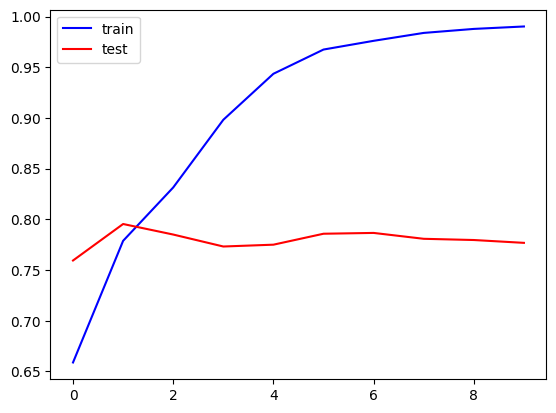

In [17]:
import matplotlib.pyplot as plt 

plt.plot(history.history['accuracy'] , color = 'blue' , label = 'train')
plt.plot(history.history['val_accuracy'] , color = 'red' , label = 'test')
plt.legend()
